In [1]:
import pandas as pd
import numpy as np

from astropy.io import fits
from pathlib import Path

import matplotlib.pyplot as plt

In [2]:
def fits_df(folder_dir):
    """
    Reads the headers of all fits files in folder_dir, and puts
    them into a DataFrame
    Parameters:
        folder_dir: directory with fits images
    Returns:
        pandas DataFrame with fits image file paths and header values
    """
    imgs = list(folder_dir.glob('*.fits'))
    headers = []

    for img_path in imgs:
        header = dict(fits.getheader(img_path))
        header["FILEPATH"] = img_path
        header["FILENAME"] = img_path.name
        headers.append(header)
        
    return pd.DataFrame(headers)

In [3]:
OUT_FEATURES = ['FLAG']
BANDS = ['f150w', 'f277w', 'f444w']
SEED = 42

# HYPERPARAMETERS
INPUT_SIZE = 67

In [4]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

## Prepare Data

In [5]:
cwd = Path.cwd()
cutout_dir = cwd.parent / 'data' / 'cutouts'
model_dir = cwd.parent / 'models'

In [6]:
# LOAD DATA INTO DF 

cols = {'idx': [],
        'images': [],
        'header': []}

for folder in cutout_dir.iterdir():
    if folder.is_dir():
        cols['idx'].append(folder.stem)

        temp_df = fits_df(folder)
        temp_df.sort_values(by='BAND')

        # load images
        temp_imgs = dict()
        for _, row in temp_df.iterrows():
            hdul = fits.open(row['FILEPATH'])
            data = hdul[0].data.astype('float32')
            header = hdul[0].header
            temp_imgs[row['BAND']] = data
            hdul.close()
        cols['images'].append(temp_imgs)
        cols['header'].append(header)

# turn dict into df and expand header columns
df = pd.DataFrame(cols)
to_expand = ['header', 'images']
for col in to_expand:
    temp_df = pd.DataFrame(df[col].tolist(), index=df.index)
    df = df.join(temp_df)
df.drop(columns=['header', 'BAND', 'images'], inplace=True)

# shuffle
if SEED:
    df = df.sample(frac=1, random_state=SEED)
else:
    df = df.sample(frac=1)

In [7]:
# GET SUBTRACTED AND DIVIDED BANDS

numers = ['f150w', 'f277w']
denominator = 'f444w'

for numerator in numers:
    df[numerator + '/' + denominator] = df[numerator] / df[denominator]
    df[denominator + '-' + numerator] = df[denominator] - df[numerator]

Text(0.5, 1.0, 'f444w-f277w')

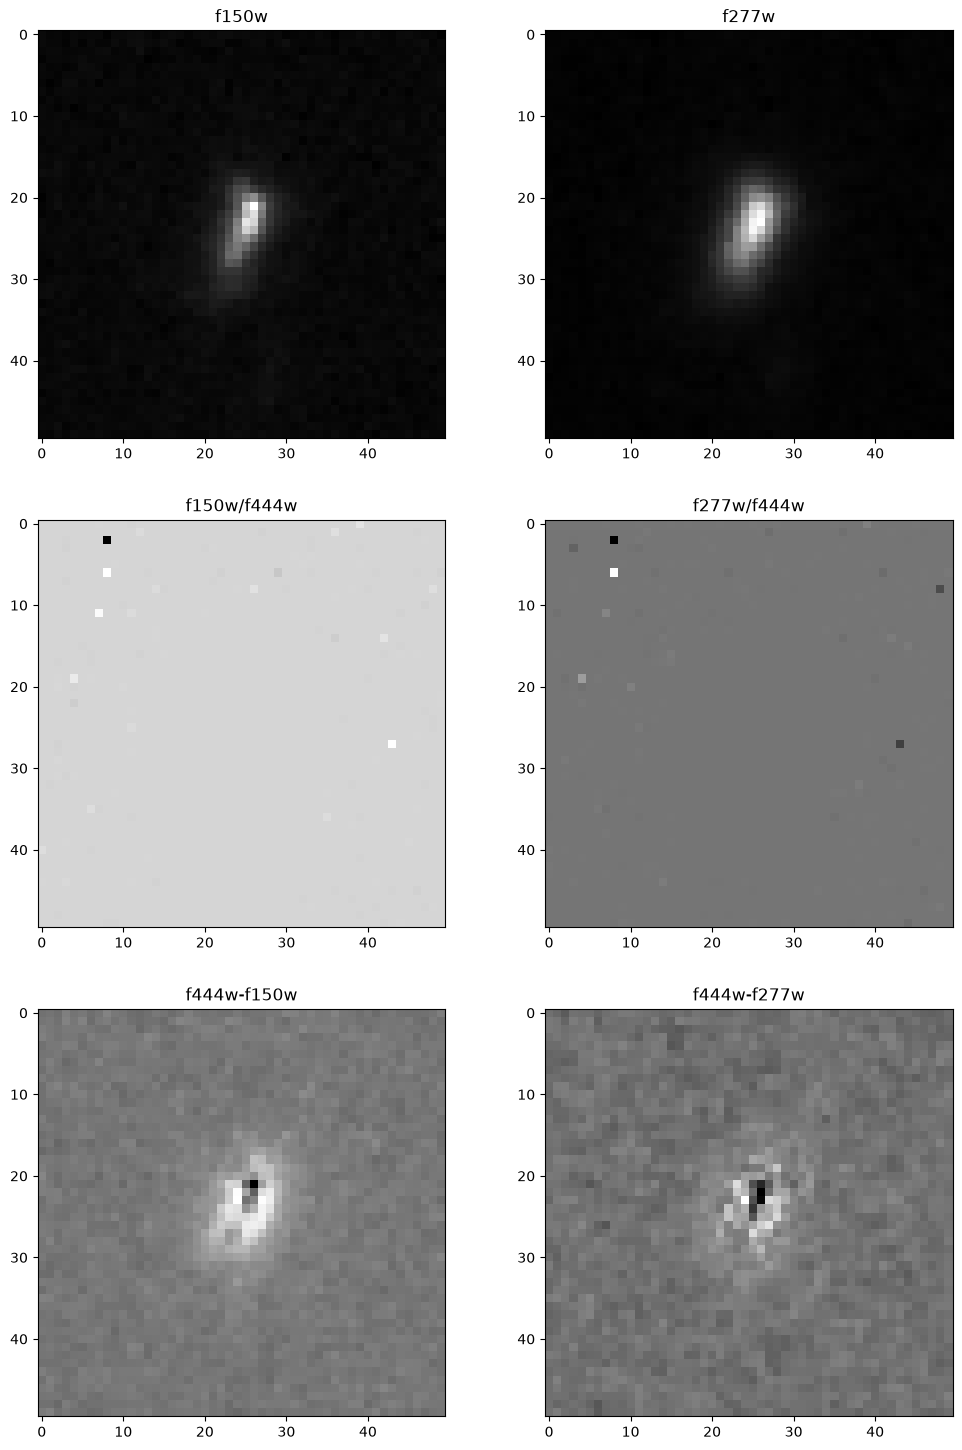

In [8]:
fig, axs = plt.subplots(ncols=2, nrows=3, figsize=(12,18))

i = 10

axs[0][0].imshow(df['f150w'][i], cmap='gray')
axs[0][0].set_title('f150w')
axs[0][1].imshow(df['f277w'][i], cmap='gray')
axs[0][1].set_title('f277w')

axs[1][0].imshow(df['f150w/f444w'][i], cmap='gray')
axs[1][0].set_title('f150w/f444w')
axs[1][1].imshow(df['f277w/f444w'][i], cmap='gray')
axs[1][1].set_title('f277w/f444w')

axs[2][0].imshow(df['f444w-f150w'][i], cmap='gray')
axs[2][0].set_title('f444w-f150w')
axs[2][1].imshow(df['f444w-f277w'][i], cmap='gray')
axs[2][1].set_title('f444w-f277w')

In [9]:
img = df['f150w/f444w'][i]

print('max: ', np.max(img), 'median: ', np.median(img), 'mean: ', np.mean(img))

max:  1044.2147 median:  0.39965934 mean:  -0.003913135
